In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:
survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
target = "survived"

X = df.drop(columns=[target])
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 14)
Testing data: (179, 14)


In [6]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


C:\Users\Kabilan\AppData\Local\Temp\ipykernel_3944\407263187.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [7]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [8]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


In [10]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

print("Complete ML pipeline created successfully.")

Complete ML pipeline created successfully.


In [11]:
model_pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [12]:
y_pred = model_pipeline.predict(X_test)

print("Predictions generated successfully.")
print(y_pred[:20])

Predictions generated successfully.
[0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 1.000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00        69

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



In [14]:
correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

print(correlation_matrix.round(2))

          survived  pclass   age  sibsp  parch  fare
survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
sibsp        -0.04    0.08 -0.31   1.00   0.41  0.16
parch         0.08    0.02 -0.19   0.41   1.00  0.22
fare          0.26   -0.55  0.10   0.16   0.22  1.00


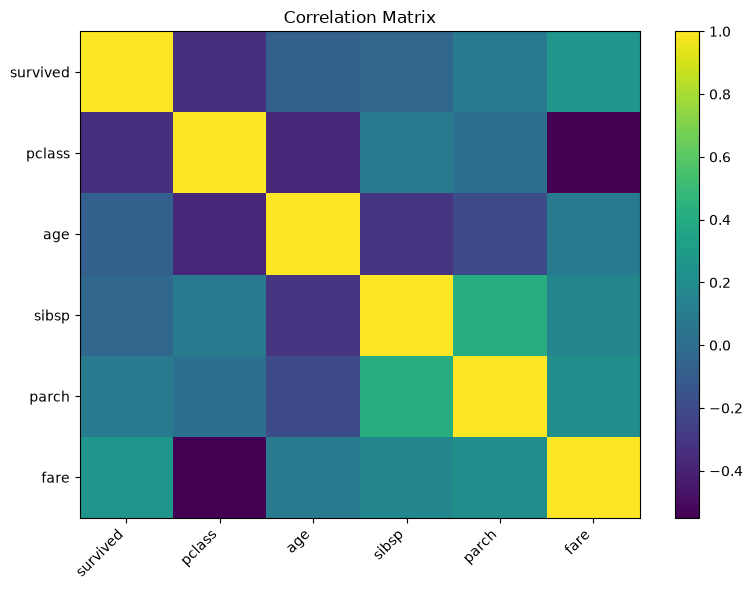

In [15]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [16]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
print(feature_names)

Number of processed features: 32

Processed feature names:
['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S' 'cat__class_First' 'cat__class_Second'
 'cat__class_Third' 'cat__who_child' 'cat__who_man' 'cat__who_woman'
 'cat__adult_male_False' 'cat__adult_male_True' 'cat__deck_A'
 'cat__deck_B' 'cat__deck_C' 'cat__deck_D' 'cat__deck_E' 'cat__deck_F'
 'cat__deck_G' 'cat__embark_town_Cherbourg' 'cat__embark_town_Queenstown'
 'cat__embark_town_Southampton' 'cat__alive_no' 'cat__alive_yes'
 'cat__alone_False' 'cat__alone_True']


In [17]:
random_forest = model_pipeline.named_steps["model"]

importance_values = random_forest.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
28,cat__alive_no,0.431577
29,cat__alive_yes,0.327460
14,cat__who_man,0.044163
17,cat__adult_male_True,0.038261
5,cat__sex_female,0.027724
16,cat__adult_male_False,0.025033
6,cat__sex_male,0.020794
4,num__fare,0.018544
12,cat__class_Third,0.011553
10,cat__class_First,0.010969


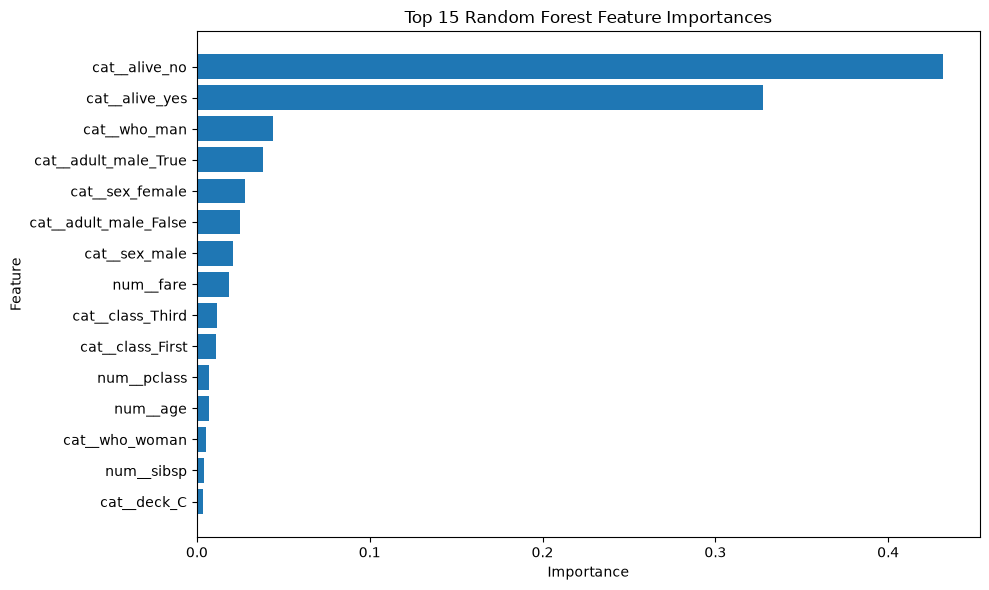

In [18]:
top_features = feature_importance.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

# Key Findings

## Preprocessing
A reusable Scikit-Learn Pipeline was created using ColumnTransformer.

Numerical features were processed using median imputation followed by StandardScaler.

Categorical features were processed using most-frequent imputation followed by OneHotEncoder with unknown-category handling.

## Leakage Prevention
The dataset was split into training and testing sets before preprocessing was fitted. The preprocessing transformations were therefore learned only from the training data through the Scikit-Learn Pipeline.

## Correlation Analysis
Correlation analysis was performed on the numerical features to understand linear relationships between variables.

## Feature Importance
A Random Forest classifier was used to calculate tree-based feature importance after preprocessing.

## Conclusion
The notebook demonstrates a reusable and leak-resistant preprocessing workflow for mixed numerical and categorical tabular data.